# 01 - EDA Textual
**PA007 · NLP Análise de Sentimento Zomato**

Objetivo desta etapa:
- Entender a distribuição de ratings e classes de sentimento
- Analisar tamanho e padrões do texto das reviews
- Identificar problemas de qualidade (missing, duplicatas, idioma)
- Extrair palavras mais frequentes por classe
- Produzir word clouds para visualização inicial
- Quantificar estatisticamente a relação entre variáveis candidatas e o target (bivariada)
- Documentar a proveniência dos dados brutos

**Input:** `data/raw/zomato_reviews.csv`
**Output:** decisões documentadas para o pré-processamento (notebook 02)


## 1. Setup e imports

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
import warnings
import numpy as np
from scipy.stats import kruskal, spearmanr, mannwhitneyu

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

# Baixar recursos NLTK necessários
for resource in ["stopwords", "punkt", "words", "wordnet", "omw-1.4"]:
    nltk.download(resource, quiet=True)

from src.preprocessing import rating_to_sentiment, eh_hinglish, preprocess_pipeline
from src.stats import chi2_cramers_v


## 2. Carregamento dos dados

**Fonte:** Kaggle, dataset [`milanvaddoriya/zomato-reviews-ratings`](https://www.kaggle.com/datasets/milanvaddoriya/zomato-reviews-ratings). Reviews e ratings numéricos de restaurantes cadastrados na plataforma Zomato.


In [2]:
df = pd.read_csv("../data/raw/zomato_reviews.csv", index_col=0)
print("Shape:", df.shape)
df.head(5)

Shape: (5479, 2)


,rating,review
0,5,nice
1,5,"best biryani , so supportive staff of outlet ,..."
2,4,delivery boy was very decent and supportive.👌👍
3,1,"worst biryani i have tasted in my life, half o..."
4,5,all food is good and tasty . will order again ...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5479 entries, 0 to 5478
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   rating  5479 non-null   int64 
 1   review  5478 non-null   object
dtypes: int64(1), object(1)
memory usage: 128.4+ KB


## 3. Qualidade dos dados

In [4]:
print("=== Missing values ===")
print(df.isnull().sum())
print()
print("=== Duplicatas ===")
print("Linhas duplicadas:", df.duplicated().sum())


=== Missing values ===
rating    0
review    1
dtype: int64

=== Duplicatas ===
Linhas duplicadas: 860


In [5]:
# Remover o único NaN em review detectado na célula anterior
df = df.dropna(subset=["review"]).copy()
print(f"Após dropna: {len(df)} linhas")

# Camada 1: duplicatas exatas (review + rating)
antes = len(df)
df = df.drop_duplicates(subset=["review", "rating"]).copy()
print(f"Camada 1 — duplicatas exatas:            -{antes - len(df):>4}  →  {len(df)} linhas")

# n_words, reaproveitado nas camadas 2 e 3 e na seção 3.1/3.2 (H1/H2)
df["n_words"] = df["review"].str.split().str.len()

# Camada 2: mesmo texto, ratings diferentes (label não confiável)
antes = len(df)
textos_conflito = (
    df.groupby("review")["rating"]
    .nunique()
    .pipe(lambda s: s[s > 1].index)
)
df_pre_camada2 = df.copy()  # snapshot usado na seção 3.1/3.2 para testar H1/H2
df = df[~df["review"].isin(textos_conflito)].copy()
print(f"Camada 2 — ratings conflitantes:         -{antes - len(df):>4}  →  {len(df)} linhas  ({len(textos_conflito)} textos únicos)")

# Camada 3: reviews com <= 2 palavras (sem sinal semântico)
antes = len(df)
removidos_camada3 = df[df["n_words"] <= 2].copy()
df = df[df["n_words"] > 2].copy()
print(f"Camada 3 — reviews <= 2 palavras:        -{antes - len(df):>4}  →  {len(df)} linhas")

# Discriminação por classe futura (sentiment só é criado na seção 5;
# aplicado aqui de forma pontual só para auditar a camada 3)
removidos_camada3["sentiment_futuro"] = removidos_camada3["rating"].apply(rating_to_sentiment)
print()
print("Remoção da camada 3 por classe futura:")
print(removidos_camada3["sentiment_futuro"].value_counts())

print(f"\nDataset final: {len(df)} linhas ({len(df)/5479*100:.1f}% do original)")


Após dropna: 5478 linhas
Camada 1 — duplicatas exatas:            - 860  →  4618 linhas
Camada 2 — ratings conflitantes:         - 668  →  3950 linhas  (280 textos únicos)
Camada 3 — reviews <= 2 palavras:        - 580  →  3370 linhas

Remoção da camada 3 por classe futura:
sentiment_futuro
positivo    289
negativo    250
neutro       41
Name: count, dtype: int64

Dataset final: 3370 linhas (61.5% do original)


### **3.1 (H1) Conflito da Camada 2 concentrado nos ratings extremos (1 e 5)**

Se não houvesse nenhuma relação entre um texto ter conflito de rating (Camada 2) e a nota dele ser extrema, a proporção de ratings extremos devia ser parecida nos dois grupos, com conflito e sem conflito. O teste pergunta justamente isso: essa proporção realmente difere, ou a diferença que aparece nos dados é só variação natural da amostra?

Teste: qui-quadrado de independência entre "removido pela Camada 2" e "rating extremo (1 ou 5) vs. meio (2, 3 ou 4)".

Hipótese: textos genéricos e de baixo esforço (`"nice"`, `"good"`) tendem a ser reciclados nos extremos da escala, um "5 estrelas no automático" ou um "1 estrela de raiva", gerando mais conflito ali do que no meio.

In [6]:
df_pre_camada2["removido_camada2"] = df_pre_camada2["review"].isin(textos_conflito)
df_pre_camada2["rating_extremo"] = df_pre_camada2["rating"].isin([1, 5])

tabela_h1 = pd.crosstab(df_pre_camada2["removido_camada2"], df_pre_camada2["rating_extremo"])
chi2_h1, p_h1, v_h1 = chi2_cramers_v(tabela_h1)

print(tabela_h1)
print(f"chi2 = {chi2_h1:.2f} | p-value = {p_h1:.3f} | V de Cramér = {v_h1:.4f}")
print()
print("Proporção de rating extremo (1 ou 5), por grupo:")
print(df_pre_camada2.groupby("removido_camada2")["rating_extremo"].mean().round(3))


rating_extremo    False  True 
removido_camada2              
False               940   3010
True                248    420
chi2 = 52.43 | p-value = 0.000 | V de Cramér = 0.1065

Proporção de rating extremo (1 ou 5), por grupo:
removido_camada2
False    0.762
True     0.629
Name: rating_extremo, dtype: float64


**Resultado:** não é coincidência, a diferença é grande demais pra ser acaso (χ²=52,43; p<0,001). Mas na direção **oposta** à esperada: reviews com conflito têm proporção *menor* de ratings extremos (62,9%) do que as sem conflito (76,2%). O conflito está relativamente mais concentrado nas notas do meio (2, 3 e 4), não nos extremos.

**H1 rejeitada na direção proposta.** O achado real é sobre onde o conflito não acontece: não são os "5 estrelas automáticos" nem os "1 estrela de raiva" que geram texto reciclado entre notas diferentes, é mais a avaliação ambígua do meio da escala. Efeito pequeno-moderado (V de Cramér = 0,107), mas robusto dado N=4.618.

### 3.2 **(H2) Conflito da Camada 2 mais frequente em reviews curtas**

Se o tamanho da review não tivesse nenhuma relação com o conflito de rating, a mediana de palavras devia ser parecida entre os textos removidos por conflito e os mantidos. O teste pergunta: essa diferença de tamanho que aparece nos dados é grande demais pra ser só variação da amostra?

Teste: Mann-Whitney U (não paramétrico, compara 2 grupos independentes) entre `n_words` dos removidos e dos mantidos.

Hipótese: textos curtos carregam menos contexto, ficam mais ambíguos e mais fáceis de reciclar sob ratings diferentes, elevando a chance de conflito.

In [7]:
grupo_removido = df_pre_camada2.loc[df_pre_camada2["removido_camada2"], "n_words"]
grupo_mantido = df_pre_camada2.loc[~df_pre_camada2["removido_camada2"], "n_words"]

u_h2, p_h2 = mannwhitneyu(grupo_removido, grupo_mantido, alternative="less")

print(f"Mediana n_words — removidos (Camada 2): {grupo_removido.median():.1f}")
print(f"Mediana n_words — mantidos:              {grupo_mantido.median():.1f}")
print(f"U = {u_h2:.0f} | p-value (H: removidos < mantidos) = {p_h2:.4f}")

Mediana n_words — removidos (Camada 2): 4.0
Mediana n_words — mantidos:              7.0
U = 1122341 | p-value (H: removidos < mantidos) = 0.0000


**Resultado:** sim, a diferença é grande demais pra ser acaso (mediana 4 palavras nos removidos vs 7 nos mantidos; U=1.122.341, p<0,0001).

**H2 confirmada.** Reforça com dado a lógica por trás da Camada 3 (remoção de reviews ≤2 palavras): o mesmo tipo de texto curto e genérico que gera conflito de rating na Camada 2 é o que a Camada 3 elimina depois por falta de sinal semântico.

## 4. Distribuição do rating

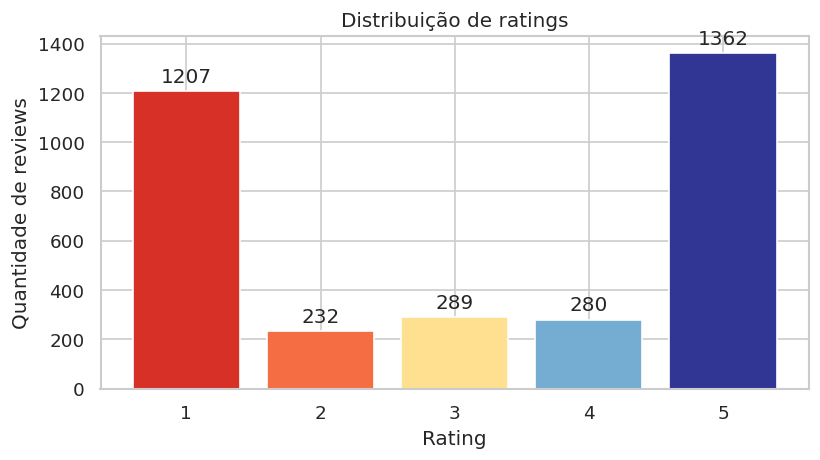

rating
1    1207
2     232
3     289
4     280
5    1362
Name: count, dtype: int64

rating
1    35.816024
2     6.884273
3     8.575668
4     8.308605
5    40.415430
Name: count, dtype: float64


In [8]:
rating_counts = df["rating"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(rating_counts.index.astype(str), rating_counts.values,
              color=["#d73027","#f46d43","#fee090","#74add1","#313695"])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Rating")
ax.set_ylabel("Quantidade de reviews")
ax.set_title("Distribuição de ratings")
plt.tight_layout()
plt.savefig("../reports/figures/01_distribuicao_rating.png")
plt.show()

print(rating_counts)
print()
print(rating_counts / len(df) * 100)


## 5. Definição das classes de sentimento

Mapeamento adotado:

| Rating | Sentimento |
|--------|-----------|
| 1 – 2  | negativo  |
| 3      | neutro    |
| 4 – 5  | positivo  |

> Decisão: manter 3 classes na EDA. Avaliar se sera necessario incluir neutro em negativo ou positivo para simplificar em binário ou remove-lo.


In [9]:
# Mapeamento em 3 classes (rating_to_sentiment em src/preprocessing.py):
# Colapsar neutro em negativo contaminaria o label negativo com tokens positivos.
#
# Positivo: rating 4-5
# Neutro:   rating 3
# Negativo: rating 1-2

df["sentiment"] = df["rating"].apply(rating_to_sentiment)

counts = df["sentiment"].value_counts()
print(counts)
print()
print((counts / len(df) * 100).round(1))


sentiment
positivo    1642
negativo    1439
neutro       289
Name: count, dtype: int64

sentiment
positivo    48.7
negativo    42.7
neutro       8.6
Name: count, dtype: float64


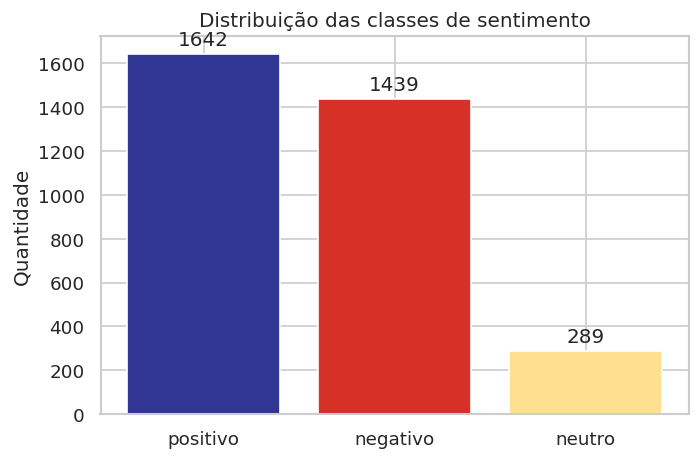

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = {"positivo": "#313695", "neutro": "#fee090", "negativo": "#d73027"}
bars = ax.bar(counts.index, counts.values,
              color=[colors[s] for s in counts.index])
ax.bar_label(bars, padding=3)
ax.set_title("Distribuição das classes de sentimento")
ax.set_ylabel("Quantidade")
plt.tight_layout()
plt.savefig("../reports/figures/01_distribuicao_sentimento.png")
plt.show()


### 5.1 Desbalanceamento da classe neutro

A classe `neutro` representa 8,6% do dataset (289 amostras), frente a aproximadamente 45% em cada uma das outras duas classes (positivo: 1.642, negativo: 1.439). É um desbalanceamento de aproximadamente 5,7:1 frente a positivo e 5:1 frente a negativo.

**Decisão:** manter as 3 classes apesar do desbalanceamento. O vocabulário do neutro é distinto do negativo (`good`, `nice`, `money` no neutro contra `bad`, `worst`, `cold` no negativo), colapsar contaminaria os labels. `class_weight='balanced'` em todos os algoritmos, para compensar o peso desproporcional das classes majoritárias na função de perda. Se `F1(neutro) < 0,45` mesmo com a mitigação, a decisão de manter 3 classes será reavaliada.


## 6. Análise do tamanho das reviews

In [11]:
# n_words já foi calculado na seção 3 (antes da Camada 2)
df["n_chars"] = df["review"].str.len()

print("=== Caracteres por review ===")
print(df["n_chars"].describe().round(1))
print()
print("=== Palavras por review ===")
print(df["n_words"].describe().round(1))

=== Caracteres por review ===
count    3370.0
mean       72.0
std        71.1
min         9.0
25%        28.0
50%        51.0
75%        91.0
max       788.0
Name: n_chars, dtype: float64

=== Palavras por review ===
count    3370.0
mean       12.9
std        12.5
min         3.0
25%         5.0
50%         9.0
75%        16.0
max       150.0
Name: n_words, dtype: float64


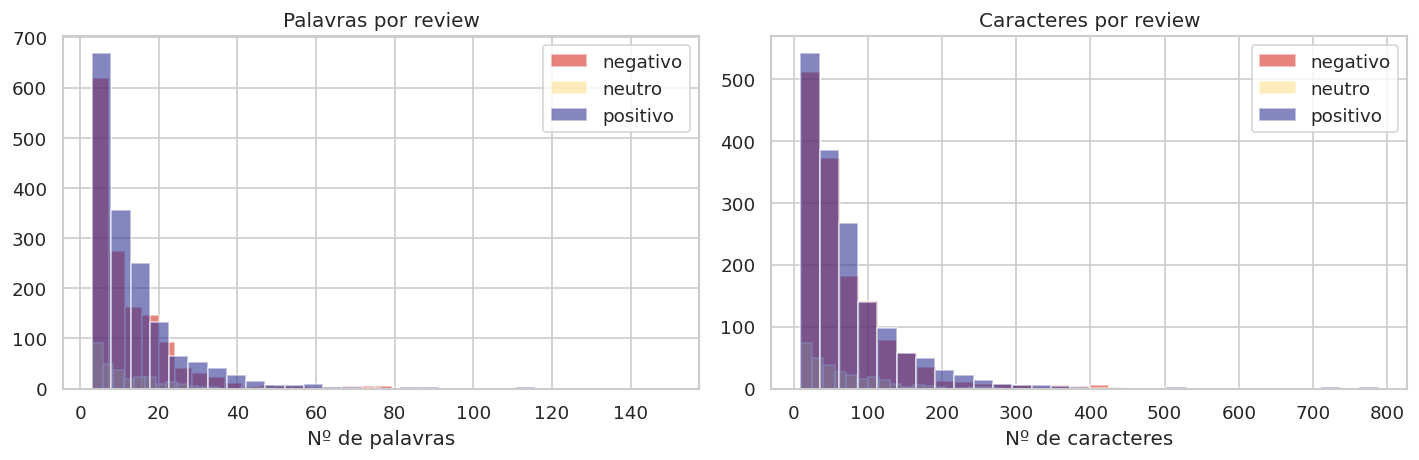

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for sent, grp in df.groupby("sentiment"):
    axes[0].hist(grp["n_words"], bins=30, alpha=0.6, label=sent,
                 color=colors[sent])
    axes[1].hist(grp["n_chars"], bins=30, alpha=0.6, label=sent,
                 color=colors[sent])

axes[0].set_title("Palavras por review")
axes[0].set_xlabel("Nº de palavras")
axes[0].legend()
axes[1].set_title("Caracteres por review")
axes[1].set_xlabel("Nº de caracteres")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/01_tamanho_reviews.png")
plt.show()


### **6.1 (H3) Tamanho da review difere entre classes de sentimento**

Se o tamanho da review não tivesse nada a ver com o sentimento do cliente, a distribuição de `n_words`/`n_chars` devia ser parecida nas três classes (positivo, neutro, negativo). O teste pergunta: as diferenças que aparecem entre as classes são grandes demais pra ser acaso?

Teste: Kruskal-Wallis (não paramétrico, adequado pra distribuição assimétrica de contagens de palavras/caracteres) comparando `n_words` e `n_chars` entre as três classes.

In [13]:
k_grupos = df["sentiment"].nunique()

grupos_words = [g["n_words"].values for _, g in df.groupby("sentiment")]
h_words, p_words = kruskal(*grupos_words)
eps2_words = (h_words - k_grupos + 1) / (len(df) - k_grupos)

grupos_chars = [g["n_chars"].values for _, g in df.groupby("sentiment")]
h_chars, p_chars = kruskal(*grupos_chars)
eps2_chars = (h_chars - k_grupos + 1) / (len(df) - k_grupos)

print("=== Kruskal-Wallis — n_words por sentiment ===")
print(f"H = {h_words:.2f} | p-value = {p_words:.3f} | epsilon2 = {eps2_words:.4f}")
print(df.groupby("sentiment")["n_words"].median())
print()
print("=== Kruskal-Wallis — n_chars por sentiment ===")
print(f"H = {h_chars:.2f} | p-value = {p_chars:.3f} | epsilon2 = {eps2_chars:.4f}")


=== Kruskal-Wallis — n_words por sentiment ===
H = 3.81 | p-value = 0.149 | epsilon2 = 0.0005
sentiment
negativo     9.0
neutro       9.0
positivo    10.0
Name: n_words, dtype: float64

=== Kruskal-Wallis — n_chars por sentiment ===
H = 4.03 | p-value = 0.133 | epsilon2 = 0.0006


**Resultado:** não, as diferenças observadas são pequenas demais, cabem dentro do que se espera por acaso (`n_words`: p=0,149; `n_chars`: p=0,133). Reviews positivas, neutras e negativas têm o mesmo tamanho típico, mediana de 9 a 10 palavras nas três. Mesmo se desse significativo, o efeito seria desprezível (ε² < 0,001).

**H3 rejeitada. Decisão:** `n_words`/`n_chars` não entram como feature candidata na modelagem.

### 6.2 **(H4) Tamanho da review correlaciona com o rating**

Se quem escreve mais (ou menos) não tivesse relação nenhuma com a nota dada, a correlação entre tamanho da review e rating devia ficar em torno de zero. O teste pergunta: a correlação observada é grande demais pra ser acaso?

Teste: correlação de Spearman (adequada pra `rating`, que é ordinal, não uma escala contínua) entre tamanho da review e rating numérico.

In [14]:
rho_words, p_rho_words = spearmanr(df["n_words"], df["rating"])
rho_chars, p_rho_chars = spearmanr(df["n_chars"], df["rating"])

print("=== Correlação de Spearman com rating ===")
print(f"n_words x rating: rho = {rho_words:.3f} | p-value = {p_rho_words:.3f}")
print(f"n_chars x rating: rho = {rho_chars:.3f} | p-value = {p_rho_chars:.3f}")


=== Correlação de Spearman com rating ===
n_words x rating: rho = 0.030 | p-value = 0.081
n_chars x rating: rho = 0.032 | p-value = 0.067


**Resultado:** não, a correlação observada é praticamente zero e cabe dentro do que se espera por acaso (`n_words`: ρ=0,030, p=0,081; `n_chars`: ρ=0,032, p=0,067).

**H4 rejeitada.** Reviews maiores não tendem a ser mais positivas nem mais negativas, o esforço de escrita é independente da satisfação do cliente neste dataset.

## 7. Verificação de idioma (amostra)

In [15]:
# Detectar Hinglish via proporção de tokens reconhecidos como inglês
# (eh_hinglish em src/preprocessing.py, NLTK words ~235k palavras)
df["hinglish"] = df["review"].apply(eh_hinglish)
hinglish_df = df[df["hinglish"]]
print(f"Reviews Hinglish (< 50% tokens ingleses): {len(hinglish_df)} ({len(hinglish_df)/len(df)*100:.1f}%)")
print()
print(hinglish_df["review"].head(10).to_string())


Reviews Hinglish (< 50% tokens ingleses): 209 (6.2%)

87                                    paav kio nhi bheja
102    spoon nahi diya hai  order k sath spoon dena c...
134          bhai ishse ghatiya kuchh nahi khaya aaj tak
148    🥄 spoon nhi tha yahi hai buss<br/>wrna or sab ...
149              masala pav aaya hai nay tu kisa star do
177                                      जादा ठिक नही था
178                                         अच्छा नही था
196    🙏🏻જય સ્વામિનારાયણ<br/><br/>બહુ સરસ કોલ્ડ કોકો ...
231    exta kaju ka 40 piya lekin 10 rupey ke bheje 🤣...
263    sab ghuli thi abhi kya kare ek dam bekar item ...


In [16]:
pct = len(hinglish_df) / len(df) * 100
print(f"Proporção Hinglish: {len(hinglish_df)}/{len(df)} ({pct:.1f}%)")
print()
print(hinglish_df["sentiment"].value_counts())

Proporção Hinglish: 209/3370 (6.2%)

sentiment
positivo    95
negativo    93
neutro      21
Name: count, dtype: int64


### **7.1 (H5) Idioma (Hinglish) associado à classe de sentimento**

Se escrever em Hinglish não tivesse nenhuma relação com o sentimento do cliente, a proporção de reviews Hinglish devia ser parecida nas três classes. O teste pergunta: a diferença observada entre as classes é grande demais pra ser acaso?

Teste: qui-quadrado de independência entre a flag `hinglish` e a classe de sentimento.

In [17]:
tabela_hinglish = pd.crosstab(df["hinglish"], df["sentiment"])
chi2_h, p_h, v_h = chi2_cramers_v(tabela_hinglish)

print(tabela_hinglish)
print(f"chi2 = {chi2_h:.2f} | p-value = {p_h:.3f} | V de Cramér = {v_h:.4f}")


sentiment  negativo  neutro  positivo
hinglish                             
False          1346     268      1547
True             93      21        95
chi2 = 1.22 | p-value = 0.543 | V de Cramér = 0.0190


**Resultado:** não, a diferença cabe dentro do que se espera por acaso (χ²=1,22; p=0,543). A proporção de reviews Hinglish é parecida nas três classes (negativo 6,5%, neutro 7,3%, positivo 5,8%).

**H5 rejeitada.** Confirma que manter os textos Hinglish não introduz viés de classe.

## 8. Palavras mais frequentes por sentimento

In [18]:
# tokenizar() local removida — usa preprocess_pipeline() de src/preprocessing.py
# (mesma limpeza usada no nb02 para alimentar o modelo: clean_text -> tokenize ->
# remove_stopwords -> lemmatize). Corrige o bug do tokenizar() antigo, que colava
# palavras vizinhas ao remover a tag <br/> sem deixar espaço no lugar.
for sent in ["positivo", "neutro", "negativo"]:
    subset = df[df["sentiment"] == sent]["review"]
    tokens = []
    for review in subset:
        tokens.extend(preprocess_pipeline(review))
    top = Counter(tokens).most_common(15)
    print(f"=== {sent.upper()} — top 15 palavras ===")
    for palavra, freq in top:
        print(f"  {palavra}: {freq}")
    print()


=== POSITIVO — top 15 palavras ===
  not: 534
  food: 367
  good: 347
  taste: 326
  order: 312
  bad: 196
  quality: 134
  no: 125
  delivery: 120
  quantity: 108
  like: 102
  time: 102
  service: 99
  restaurant: 93
  less: 77

=== NEUTRO — top 15 palavras ===
  not: 85
  food: 60
  taste: 59
  good: 55
  bad: 54
  order: 41
  delivery: 29
  money: 28
  restaurant: 24
  quality: 22
  best: 22
  service: 19
  no: 17
  give: 17
  also: 17

=== NEGATIVO — top 15 palavras ===
  not: 498
  order: 291
  good: 281
  food: 273
  taste: 247
  bad: 180
  no: 120
  quality: 111
  delivery: 105
  like: 103
  quantity: 96
  test: 95
  restaurant: 91
  service: 88
  time: 81



### Alerta: palavras negativas na classe positivo

`bad` aparece **196×** na classe **positivo** e `good` **281×** na classe **negativo** (números do pipeline com POS tagging real, `src/preprocessing.py`, correção feita apos avanco do projeto). Três fenômenos explicam isso:

1. **Negação não capturada:** `"not bad"` (= positivo) é tokenizado como `bad` - o bag-of-words perde o contexto da negação.
2. **Contraste intra-review:** `"service was bad but food was amazing"` (rating 4) - review positiva com palavra negativa dentro.
3. **Fusão lexical `worst`/`worse` → `bad`:** o `WordNetLemmatizer`, agora com a classe gramatical correta, trata `worst` e `worse` como formas irregulares do mesmo adjetivo que `bad` (confirmado no dicionário WordNet, não é bug). `worst` deixa de existir como token próprio no vocabulário.

TF-IDF com unigramas puro cometerá erros sistemáticos aqui. Estratégias a testar:
- `ngram_range=(1, 2)` - captura `not bad`, `not good`, `very bad`, `so good`
- Análise de falsos positivos/negativos focada em reviews com `bad`/`good` fora do contexto esperado

**Atualização (correção de contrações, mesma sessão):** `not` era invisível pro modelo até aqui, `nltk.word_tokenize` cortava contrações (`didn't`→`did`+`n't`) de um jeito que a negação virava um fragmento sem sentido (`nt`) ou era removida como stopword. Corrigido em `src/preprocessing.py` (`expand_contractions()` + `not`/`no`/`nor` fora da lista de stopwords, ver `02_preprocessing.ipynb`). Efeito: `not` passou a ser a **palavra mais frequente do vocabulário** em positivo (534x) e negativo (498x), à frente até de `food`. Pré-condição que faltava pra `ngram_range=(1,2)` capturar negação de verdade no nb03.

### **8.1 (H6) Tokens `bad`/`good`/`worst` associados à classe de sentimento**

Se a presença desses tokens não tivesse nenhuma relação com o sentimento do cliente, a taxa de ocorrência de `bad`/`good`/`worst` devia ser parecida nas três classes. O teste pergunta: as diferenças observadas são grandes demais pra ser acaso?

Teste: qui-quadrado de independência (presença do token × classe de sentimento), pra quantificar estatisticamente o alerta observado acima. Incluído `worst` como contraste, token intuitivamente associado a insatisfação.

In [19]:
def chi2_token(token, target_col):
    presente = df["review"].str.lower().str.contains(rf"\b{token}\b", regex=True)
    tabela = pd.crosstab(presente, df[target_col])
    chi2, p, v = chi2_cramers_v(tabela)
    return chi2, p, v, tabela

for token in ["bad", "good", "worst"]:
    chi2, p, v, tabela = chi2_token(token, "sentiment")
    print(f"=== '{token}' x sentiment ===")
    print(tabela)
    print(f"chi2 = {chi2:.2f} | p-value = {p:.3f} | V de Cramér = {v:.4f}")
    print()


=== 'bad' x sentiment ===
sentiment  negativo  neutro  positivo
review                               
False          1312     258      1510
True            127      31       132
chi2 = 2.41 | p-value = 0.299 | V de Cramér = 0.0268

=== 'good' x sentiment ===
sentiment  negativo  neutro  positivo
review                               
False          1203     249      1351
True            236      40       291
chi2 = 2.97 | p-value = 0.227 | V de Cramér = 0.0297

=== 'worst' x sentiment ===
sentiment  negativo  neutro  positivo
review                               
False          1367     276      1571
True             72      13        71
chi2 = 0.81 | p-value = 0.666 | V de Cramér = 0.0155



**Resultado:** não, nenhuma das três diferenças é grande demais pra ser acaso, nem mesmo `worst` (χ²=0,81; p=0,666), token intuitivamente associado a insatisfação. As taxas de ocorrência são quase idênticas entre as três classes (`worst`: 5,0% negativo, 4,5% neutro, 4,3% positivo).

**H6 rejeitada.** Confirma a hipótese de label noise estrutural: nem os tokens mais óbvios de sentimento carregam sinal discriminativo neste dataset.

### **8.2 (H7) Tokens negativos em rating alto, positivos em rating baixo (granularidade fina)**

Se `bad`/`good`/`worst` não tivessem nenhuma relação com a nota dada, a taxa de ocorrência deles devia ser parecida nos 5 ratings. O teste pergunta: alguma dessas taxas destoa demais pra ser acaso, principalmente em rating 5 (pra `bad`/`worst`) ou rating 1 (pra `good`)?

Teste: qui-quadrado de independência entre a presença de cada token e o `rating` bruto (1 a 5), em vez da classe agregada testada em 8.1.

Hipótese-mãe do projeto: se `bad`/`worst` aparecem numa taxa desproporcional em rating 5 (ou `good` em rating 1).

In [20]:
for token in ["bad", "good", "worst"]:
    chi2, p, v, tabela = chi2_token(token, "rating")
    print(f"=== '{token}' x rating ===")
    print(tabela)
    print(f"chi2 = {chi2:.2f} | p-value = {p:.3f} | V de Cramér = {v:.4f}")
    taxa_por_rating = (tabela.loc[True] / tabela.sum(axis=0) * 100).round(1)
    print(f"% de reviews com '{token}' por rating: {taxa_por_rating.to_dict()}")
    print()


=== 'bad' x rating ===
rating     1    2    3    4     5
review                           
False   1101  211  258  256  1254
True     106   21   31   24   108
chi2 = 2.55 | p-value = 0.635 | V de Cramér = 0.0275
% de reviews com 'bad' por rating: {1: 8.8, 2: 9.1, 3: 10.7, 4: 8.6, 5: 7.9}

=== 'good' x rating ===
rating     1    2    3    4     5
review                           
False   1009  194  249  235  1116
True     198   38   40   45   246
chi2 = 3.63 | p-value = 0.459 | V de Cramér = 0.0328
% de reviews com 'good' por rating: {1: 16.4, 2: 16.4, 3: 13.8, 4: 16.1, 5: 18.1}

=== 'worst' x rating ===
rating     1    2    3    4     5
review                           
False   1144  223  276  267  1304
True      63    9   13   13    58
chi2 = 1.68 | p-value = 0.794 | V de Cramér = 0.0224
% de reviews com 'worst' por rating: {1: 5.2, 2: 3.9, 3: 4.5, 4: 4.6, 5: 4.3}



**Resultado:** não, nenhuma taxa destoa o suficiente pra ser acaso (`bad`: p=0,635; `good`: p=0,459; `worst`: p=0,794). Contra-intuitivamente, `bad` tem sua *menor* taxa justamente em rating 5 (7,9%), e `worst` tem sua *maior* taxa em rating 1 (5,2%), mas a margem é pequena e não significativa.

**H7 rejeitada.** Reforça, agora no nível de rating bruto (não só na classe agregada), a mesma conclusão de label noise estrutural já vista em 8.1: nem os tokens de sentimento mais óbvios discriminam a nota do cliente neste dataset.

## 9. Word clouds por sentimento

Geradas a partir de `preprocess_pipeline()` (`src/preprocessing.py`), o mesmo pipeline usado no notebook 02 para alimentar o modelo, garantindo consistência entre a nuvem de palavras, a análise de frequência da seção 8 e o vocabulário que o modelo realmente vê.


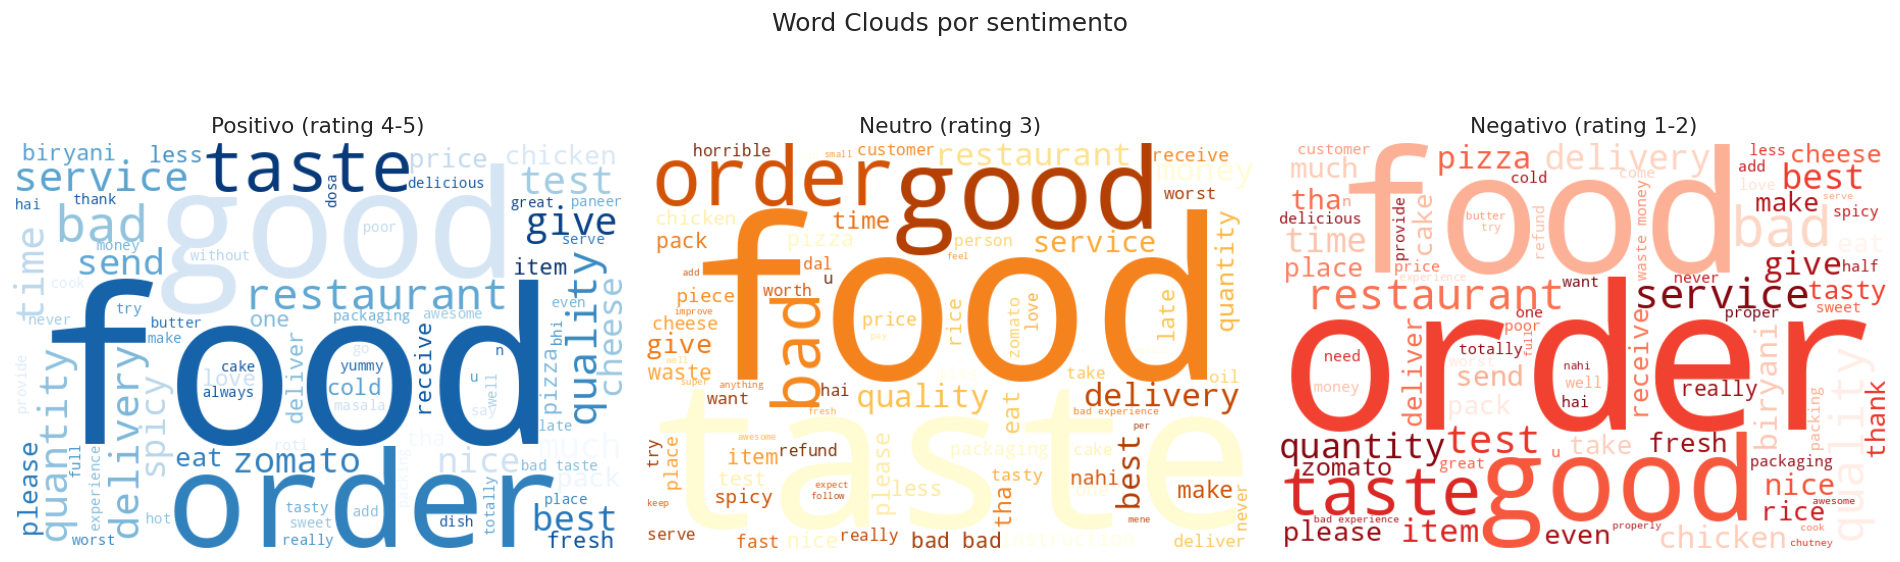

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sentimentos = ["positivo", "neutro", "negativo"]
titulos = ["Positivo (rating 4-5)", "Neutro (rating 3)", "Negativo (rating 1-2)"]
cmaps = ["Blues", "YlOrBr", "Reds"]

for ax, sent, titulo, cmap in zip(axes, sentimentos, titulos, cmaps):
    subset = df[df["sentiment"] == sent]["review"]
    texto_concat = " ".join(
        " ".join(preprocess_pipeline(review)) for review in subset
    )
    wc = WordCloud(
        width=600, height=400,
        colormap=cmap,
        background_color="white",
        max_words=80
    ).generate(texto_concat)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(titulo, fontsize=13)

plt.suptitle("Word Clouds por sentimento", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/01_wordclouds_sentimento.png", bbox_inches="tight")
plt.show()


## 10. Conclusões e decisões para o pré-processamento

### Achados da EDA

| Item | Valor |
|---|---|
| Shape original | 5.479 linhas |
| Após `dropna` (1 NaN em `review`) | 5.478 linhas |
| Camada 1, duplicatas exatas | −860 → 4.618 linhas |
| Camada 2, ratings conflitantes | −668 (280 textos únicos) → 3.950 linhas |
| Camada 3, reviews ≤ 2 palavras | −580 → 3.370 linhas |
| Camada 3 removida por classe futura | positivo 289 (15,0%) / negativo 250 (14,8%) / neutro 41 (12,4%) do total de cada classe, sem viés desproporcional contra o neutro |
| **Shape final** | **3.370 linhas (61,5% do original)** |
| Distribuição final | positivo 48,7% / neutro 8,6% / negativo 42,7% |
| Tamanho médio das reviews | ~13 palavras (mediana: 9) |
| Reviews Hinglish (NLTK words, limiar 50%) | 209 (6,2%), reviews com <50% tokens não-ingleses |

> **Nota sobre Hinglish:** a heurística NLTK identifica reviews onde a maioria dos tokens não é reconhecida como inglês. Reviews com palavras hindi soltas entre texto inglês passam pelo filtro (ex: *"best biryani ever zabardast"* tem tokens ingleses suficientes). A proporção de reviews com qualquer mistura hindi é maior que 6,2%, mas a decisão de manter todas permanece inalterada.

### Decisões tomadas

- **Classes: 3 classes mantidas** (positivo / neutro / negativo). Ver seção 5.1 para o desbalanceamento do neutro e a mitigação prevista
  - Vocabulário do neutro é distinto do negativo, colapsar contaminaria os labels
  - Se F1(neutro) < 0,45 → reavaliar colapso com dados na mão
- **Idioma:** Hinglish mantido. Tokens são consistentes; filtrar perderia parcela significativa dos dados
- **Camada 2 foi crítica:** `good` aparecia com ratings 1–5, ruído semântico puro. H1 e H2 (seção 3.1/3.2) validam estatisticamente essa camada: o conflito de rating removido é mais frequente em textos curtos (H2) e concentrado nas notas centrais, não nos extremos (H1)
- **Alerta de negação:** `bad` aparece 196× no positivo (número pós-correção de POS tagging, ver seção 8 e `02_preprocessing.ipynb` §5.2), testar `ngram_range=(1, 2)`
- **Correção de contrações:** `not` era invisível pro modelo (cortado pelo tokenizador em fragmentos sem sentido ou removido como stopword), corrigido em `src/preprocessing.py`. Agora é a palavra mais frequente do vocabulário em positivo e negativo, pré-condição pro `ngram_range=(1,2)` capturar negação de verdade

### Hipóteses testadas (bivariada quantificada, seções 3.1, 3.2, 6.1, 6.2, 7.1, 8.1, 8.2)

| # | Teste | Variáveis | Resultado | Conclusão |
|---|---|---|---|---|
| H1 | Qui-quadrado | conflito Camada 2 × rating extremo (1 ou 5) | χ²=52,43; p<0,001 (**sig.**) | conflito NÃO se concentra nos extremos, é relativamente maior nas notas centrais (2, 3, 4) |
| H2 | Mann-Whitney U | conflito Camada 2 × `n_words` | U=1.122.341; p<0,0001 (**sig.**) | reviews com conflito são mais curtas (mediana 4 vs 7 palavras) |
| H3 | Kruskal-Wallis | `n_words`/`n_chars` × sentiment | p=0,149 / 0,133 (n.s.) | tamanho da review não discrimina classe |
| H4 | Spearman | `n_words`/`n_chars` × rating | ρ=0,030 / 0,032 (n.s.) | tamanho da review não correlaciona com rating |
| H5 | Qui-quadrado | `hinglish` × sentiment | p=0,543 (n.s.) | proporção de Hinglish é semelhante entre classes |
| H6 | Qui-quadrado | `bad`/`good`/`worst` × sentiment | p=0,299 / 0,227 / 0,666 (n.s.) | nem `worst` discrimina, confirma label noise |
| H7 | Qui-quadrado | `bad`/`good`/`worst` × rating (granularidade fina) | p=0,635 / 0,459 / 0,794 (n.s.) | mesmo no rating bruto, tokens de sentimento não discriminam |

Resumo: das 7 hipóteses, 5 foram rejeitadas e 2 confirmadas, mas na direção oposta do que se esperava sobre sentimento.

- H3 a H7 rejeitadas: nenhuma variável isolada (tamanho do texto, idioma, tokens como bad/good/worst) discrimina o sentimento do cliente, nem contra a classe agregada nem contra o rating bruto.
- H1 e H2 confirmadas, mas sobre outra coisa: as duas únicas diferenças reais encontradas não são sobre sentimento, são sobre qualidade de dado. O conflito de rating que a Camada 2 remove se concentra nas notas do meio (H1) e em textos curtos (H2), o oposto do que se esperava.

Isso reforça a conclusão central da EDA: o sinal do target não está em nenhuma variável isolada, está em combinações de tokens (bigramas, negação), e o teto de F1 dos próximos notebooks vem do dado, não do algoritmo.

### Próximo passo, Notebook 02

- lowercase, remoção de pontuação e stopwords (NLTK english)
- Avaliar lemmatização (custo vs ganho no dataset de 3.370 linhas)
- Train/test split **antes** do TF-IDF fit
- `max_features` TF-IDF: começar com 5.000; `ngram_range=(1, 2)` como variante a comparar


## 11. Salvar dataset processado

In [22]:
import os

os.makedirs("../data/processed", exist_ok=True)
out_path = "../data/processed/zomato_reviews_clean.csv"
df[["rating", "review", "sentiment"]].to_csv(out_path, index=False)

print(f"Salvo em: {out_path}")
print(f"Shape: {df[['rating','review','sentiment']].shape}")
print()
print(df[["rating", "review", "sentiment"]].head(5).to_string())


Salvo em: ../data/processed/zomato_reviews_clean.csv
Shape: (3370, 3)

   rating                                                                                                    review sentiment
1       5  best biryani , so supportive staff of outlet , personalize my order on call as I say. full Paisa vasool   positivo
2       4                                                            delivery boy was very decent and supportive.👌👍  positivo
3       1                               worst biryani i have tasted in my life, half of the biryani is in dustbin.   negativo
4       5               all food is good and tasty . will order again and lots more to explore in bawarchi's menu.   positivo
5       5                                             shandar zabardast zindabad .. good going bawarchi keep it up   positivo
